# Uncertainty Quantification for LLM-Generated Cybersecurity Mitigations

**Method:** Predictive Entropy & Semantic Entropy, based on Kuhn, Gal & Farquhar, *"Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation"*, ICLR 2023, and the updated Nature 2024 paper *"Detecting Hallucinations in Large Language Models Using Semantic Entropy."*

**Adaptation for structured outputs:** the original method targets short-form QA. We adapt it for long-form structured JSON (cybersecurity mitigation lists) by: (1) converting JSON to natural language before NLI clustering, (2) using a Monte Carlo entropy estimator that stays in log-space to avoid numerical collapse for long sequences, (3) applying length normalization to make entropy comparable across attacks with different output lengths.

**LLM:** DeepSeek R1 8B — from the [HORSE-GenAI-CKB](https://github.com/martel-innovate/HORSE-GenAI-CKB) model list.

**Data:** Real CAPEC attack–mitigation pairs, fetched live from the HORSE repo.

**Backends:** CUDA GPU → HuggingFace 4-bit (auto-detected) | Apple Silicon → Ollama (auto-detected)

---
## Background

### The problem

When an LLM generates cybersecurity mitigations, we have no guarantee the output is reliable. The model might hallucinate non-existent techniques, suggest irrelevant countermeasures, or contradict itself across runs. We need a principled way to **quantify how uncertain** the model is about its output.

### Predictive entropy (PE)

Sample $M$ responses $s_1, \dots, s_M$ from the model for the same prompt. Each response has a sequence log-probability $\log p(s_i|x) = \sum_t \log p(\text{token}_t | \text{context})$. Predictive entropy is the Monte Carlo estimate of the true conditional entropy:

$$PE = -\frac{1}{M}\sum_{i=1}^{M} \log p(s_i | x)$$

This is the average negative log-likelihood — how "surprised" the model is by its own outputs. No normalization or exponentiation needed. Corresponds to `regular_entropy` in the Kuhn et al. codebase.

**Limitation:** PE treats every lexically distinct response as separate. "Use a WAF" and "Deploy a web application firewall" are counted as different outcomes, inflating the entropy with phrasing variation.

### Semantic entropy (SE) — Kuhn et al. 2023

Semantic entropy fixes this by **clustering responses by meaning** before computing entropy:

1. **Cluster** responses into semantic equivalence classes $C_1, \dots, C_K$ using bidirectional NLI entailment (DeBERTa-Large-MNLI). Two responses are equivalent iff A entails B **and** B entails A.
2. **Aggregate** log-probabilities within each cluster: $\log p(C_k) = \text{logsumexp}(\log p(s_i) : s_i \in C_k)$.
3. **Compute** entropy weighted by cluster frequencies: $SE = -\sum_k \frac{|C_k|}{M} \cdot \log p(C_k)$.

This is a Monte Carlo estimate of $H[C|x]$ — the entropy of the model's distribution over **meanings**, not strings. It stays entirely in log-space (no exponentiation of sequence probabilities), making it numerically stable even for long outputs.

**Key property:** $SE \leq PE$ always. The gap $PE - SE$ is the phrasing uncertainty (irrelevant) that clustering removes. When $SE \approx PE$, the model genuinely disagrees about the answer. When $SE \ll PE$, it says the same thing in different words.

### Discrete semantic entropy (DSE)

A simpler variant that uses only cluster counts, no log-probs: $DSE = -\sum_k \frac{|C_k|}{M} \log \frac{|C_k|}{M}$. Range $[0, \log M]$. Naturally length-independent. Called `cluster_assignment_entropy` in the paper. Works as a black-box metric when log-probs are unavailable.

### Length normalization

Sequence log-probabilities scale with output length (more tokens → more negative → higher entropy). To compare PE and SE across attacks with different output lengths, we divide by the average token count: $PE_{\text{norm}} = PE / \bar{T}$, $SE_{\text{norm}} = SE / \bar{T}$. This gives **per-token entropy** — comparable across attacks. DSE requires no normalization (it doesn't use log-probs).

### Three metrics computed in this notebook

| Metric | Formula | Comparable | What it measures |
|--------|---------|------------|-----------------|
| $PE_{\text{norm}}$ | $-\frac{1}{M\bar{T}}\sum_i \log p(s_i|x)$ | Yes | Per-token surprise (total uncertainty) |
| $SE_{\text{norm}}$ | $-\frac{1}{\bar{T}}\sum_k \frac{|C_k|}{M} \cdot \text{logsumexp}(C_k)$ | Yes | Per-token semantic uncertainty |
| $DSE$ | $-\sum_k \frac{|C_k|}{M} \log \frac{|C_k|}{M}$ | Yes | Cluster disagreement (no log-probs) |

All three are comparable across attacks. $SE_{\text{norm}} \leq PE_{\text{norm}}$ always. Higher values = more uncertain = less reliable.

---
## 0. Install dependencies

In [1]:
import platform, subprocess, sys

# Core deps (always needed)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers', 'accelerate', 'sentence-transformers',
    'pandas', 'matplotlib', 'seaborn', 'requests', 'scikit-learn', 'scipy'])

# bitsandbytes only works on CUDA — skip on Mac to avoid install errors
import torch
if torch.cuda.is_available():
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'bitsandbytes'])
    print('bitsandbytes installed (CUDA detected)')
else:
    print('Skipping bitsandbytes (no CUDA) — will use Ollama backend')

Skipping bitsandbytes (no CUDA) — will use Ollama backend


## 1. Imports & configuration

In [2]:
import numpy as np
import pandas as pd
import torch
import platform
import subprocess
import requests
import json
import warnings
from scipy.special import logsumexp
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline as hf_pipeline
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*pad_token_id.*")
warnings.filterwarnings("ignore", message=".*pipelines sequentially.*")

# ── Parameters ──────────────────────────────────────────────
M = 8                  # responses per query
TEMPERATURE = 0.8      # as recommended by Kuhn et al.
MAX_NEW_TOKENS = 512   # real CAPEC mitigations can be long
COSINE_THRESHOLD = 0.8
MAX_ATTACKS = 110       # set to None for full run (350+)
LLM_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
OLLAMA_MODEL = "deepseek-r1:8b"  # equivalent Ollama tag

## 2. Auto-detect backend

Detects the runtime environment and picks the best available backend:
- **CUDA GPU** → HuggingFace with 4-bit quantization (Colab / Linux with NVIDIA GPU)
- **Apple Silicon** → Ollama local server (M1/M2/M3/M4 Mac, needs `ollama serve` running)
- **CPU-only** → Ollama fallback

In [3]:
# ── Detect hardware ─────────────────────────────────────────
HAS_CUDA = torch.cuda.is_available()
IS_MAC_ARM = platform.system() == "Darwin" and platform.machine() == "arm64"
HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

def ollama_available():
    """Check if Ollama is running and has the required model."""
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=3)
        models = [m["name"] for m in r.json().get("models", [])]
        if OLLAMA_MODEL in models or OLLAMA_MODEL.split(":")[0] in [m.split(":")[0] for m in models]:
            return True
        print(f"Ollama running but model '{OLLAMA_MODEL}' not found.")
        print(f"Available: {models}")
        print(f"Run: ollama pull {OLLAMA_MODEL}")
        return False
    except Exception:
        return False

if HAS_CUDA:
    BACKEND = "huggingface"
    DEVICE = "cuda"
    print(f"CUDA detected ({torch.cuda.get_device_name(0)}) → HuggingFace backend")
elif ollama_available():
    BACKEND = "ollama"
    DEVICE = "mps" if HAS_MPS else "cpu"
    print(f"Ollama detected → Ollama backend (torch device: {DEVICE})")
else:
    BACKEND = None
    DEVICE = "cpu"
    print("ERROR: No CUDA GPU and no Ollama server detected.")
    print("  Option A (Mac): install Ollama → brew install ollama && ollama serve")
    print(f"                   then: ollama pull {OLLAMA_MODEL}")
    print("  Option B (Colab): Runtime → Change runtime type → T4 GPU")
    raise RuntimeError("No usable LLM backend found.")

print(f"\nBackend: {BACKEND}  |  Device: {DEVICE}")

Ollama detected → Ollama backend (torch device: mps)

Backend: ollama  |  Device: mps


## 3. Load models

Three models loaded simultaneously:

- **DeepSeek R1 8B** — the LLM. Generates mitigation JSON responses. On CUDA: HuggingFace 4-bit quantization (~5 GB VRAM). On Mac: via Ollama server.
- **all-MiniLM-L6-v2** (~80 MB) — Sentence-BERT. Encodes responses into 384-dim vectors for cosine-based clustering.
- **DeBERTa-Large-MNLI** (~1.5 GB) — NLI classifier. Determines bidirectional entailment for Kuhn et al.'s semantic clustering. This is the same model family used in the original paper.

In [4]:
# ── LLM ─────────────────────────────────────────────────────
if BACKEND == "huggingface":
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
    tokenizer.pad_token = tokenizer.eos_token
    llm = AutoModelForCausalLM.from_pretrained(
        LLM_NAME, quantization_config=bnb_config, device_map="auto"
    )
    llm.eval()
    print(f"LLM loaded: {LLM_NAME} (HuggingFace 4-bit)")
else:
    print(f"LLM: Ollama → {OLLAMA_MODEL} (running on localhost:11434)")

# ── Sentence-BERT ───────────────────────────────────────────
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)
print("Sentence-BERT loaded.")

# ── DeBERTa NLI ─────────────────────────────────────────────
nli_device = 0 if HAS_CUDA else (-1 if DEVICE == "cpu" else "mps")
# MPS can be flaky with some HF pipelines — fall back to CPU if needed
try:
    nli = hf_pipeline("text-classification", model="microsoft/deberta-large-mnli", device=nli_device)
except Exception:
    nli = hf_pipeline("text-classification", model="microsoft/deberta-large-mnli", device=-1)
    print("(DeBERTa fell back to CPU)")
print("DeBERTa-Large-MNLI loaded.")
print("\nAll models ready.")

LLM: Ollama → deepseek-r1:8b (running on localhost:11434)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence-BERT loaded.


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/jacopotalpini/Desktop/MARTEL/martel_env/lib/python3.10/site-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/Users/jacopotalpini/Desktop/MARTEL/martel_env/lib/python3.10/site-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_referenc

DeBERTa-Large-MNLI loaded.

All models ready.


## 4. Load CAPEC data from the HORSE repo

In [5]:
CAPEC_URL = (
    "https://raw.githubusercontent.com/martel-innovate/HORSE-GenAI-CKB/"
    "main/output/scraper/capec.csv"
)

capec_df = pd.read_csv(CAPEC_URL)
print(f"CSV shape: {capec_df.shape}  |  Columns: {list(capec_df.columns)}")

# ── Auto-detect columns ────────────────────────────────────
cols_lower = {c.lower().strip(): c for c in capec_df.columns}

attack_col = None
for candidate in ["attack", "attacks", "attack_name", "name", "attack pattern", "attack_pattern"]:
    if candidate in cols_lower:
        attack_col = cols_lower[candidate]
        break

mitigation_col = None
for candidate in ["mitigations", "mitigation", "mitigation_list", "solutions"]:
    if candidate in cols_lower:
        mitigation_col = cols_lower[candidate]
        break

assert attack_col and mitigation_col, (
    f"Could not detect columns. Found: {list(capec_df.columns)}. "
    f"Set attack_col and mitigation_col manually."
)
print(f"Attack column → '{attack_col}'  |  Mitigation column → '{mitigation_col}'")

# ── Build attack list ───────────────────────────────────────
attacks = []
for _, row in capec_df.iterrows():
    a = str(row[attack_col]).strip()
    m = str(row[mitigation_col]).strip()
    if a and a != "nan" and m and m != "nan":
        attacks.append({"attack": a, "mitigations": m})

print(f"{len(attacks)} attacks loaded.")
if MAX_ATTACKS is not None:
    attacks = attacks[:MAX_ATTACKS]
    print(f"Using first {MAX_ATTACKS} (set MAX_ATTACKS = None for full run).")

CSV shape: (350, 2)  |  Columns: ['attacks', 'mitigations']
Attack column → 'attacks'  |  Mitigation column → 'mitigations'
350 attacks loaded.
Using first 110 (set MAX_ATTACKS = None for full run).


## 5. Prompt template

Identical to `mitigation_generator.py` line 25.

In [6]:
def build_prompt(attack, mitigations):
    return (
        f"return a list of mitigation names and their priority, in json format, "
        f"for the attack '{attack}', including and expanding this mitigation list "
        f"according to CAPEC {mitigations}. Please generate data in the following "
        f"JSON format: The root object contains a key named 'mitigations', 'mitigations' "
        f"should be an array of objects and each object in the 'mitigations' array should "
        f"have two fields: 'name' (A string that provides the name of the mitigation), "
        f"'priority' (An integer that indicates the priority of the mitigation, with 1 being "
        f"the highest priority). Priorities are ordered unique numbers, where 1 means that "
        f"the mitigation is urgent and will be applied first, then all the others will be "
        f"applied in order and there can't be two mitigations with the same priority. "
        f"In the response I just want the json with no other text"
    )

## 6. Generate M responses with log-probabilities

For each prompt, we sample $M$ independent responses using `temperature = 0.7` (as recommended by Kuhn et al.). Each sample returns:

- **text** — the raw generated string (JSON with mitigations)
- **log\_prob** — sequence log-probability: $\log p(s|x) = \sum_{t=1}^{T} \log p(\text{token}_t | \text{context})$
- **n\_tokens** — number of generated tokens $T$ (needed for length normalization)

Two backends with identical interface:
- **HuggingFace:** `model.generate(output_scores=True)` → per-token logits → sum of log-softmax at each position.
- **Ollama:** `/api/generate` with `logprobs: true` → list of `{token, logprob}` objects → sum.

In [7]:
def _sample_huggingface(prompt, m, temperature):
    """Sample via HuggingFace generate() with output_scores."""
    messages = [{"role": "user", "content": prompt}]
    chat_input = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to(llm.device)
    prompt_len = inputs["input_ids"].shape[1]

    results = []
    for i in range(m):
        with torch.no_grad():
            output = llm.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=temperature,
                do_sample=True,
                return_dict_in_generate=True,
                output_scores=True,
            )
        gen_ids = output.sequences[0, prompt_len:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True)

        log_prob = 0.0
        for t, scores in enumerate(output.scores):
            if t >= len(gen_ids):
                break
            log_probs_t = torch.log_softmax(scores[0], dim=-1)
            log_prob += log_probs_t[gen_ids[t]].item()

        n_tokens = len(gen_ids)
        results.append({"text": text, "log_prob": log_prob, "n_tokens": n_tokens})
        print(f"    sample {i+1}/{m}  (log_prob={log_prob:.1f}, tokens={n_tokens})")
    return results


def _sample_ollama(prompt, m, temperature):
    """Sample via Ollama /api/generate with logprobs."""
    results = []
    for i in range(m):
        resp = requests.post("http://localhost:11434/api/generate", json={
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False,
            "think": False,  # disable <think> reasoning — we need the JSON directly
            "options": {
                "temperature": temperature,
                "num_predict": MAX_NEW_TOKENS,
            },
            # Request log-probs (Ollama >= 0.12.11)
            "logprobs": True,
        }, timeout=300)
        data = resp.json()
        text = data.get("response", "")

        # DeepSeek R1 may still put content in 'thinking' field
        if not text.strip():
            text = data.get("thinking", "")
            if text and i == 0:
                print("    (using 'thinking' field — model used chain-of-thought)")

        # Extract log-prob: Ollama (>= 0.12.11) returns logprobs as
        # a list of {"token": str, "logprob": float, ...} objects.
        logprobs_list = data.get("logprobs", None)
        if isinstance(logprobs_list, list) and len(logprobs_list) > 0:
            log_prob = sum(entry["logprob"] for entry in logprobs_list
                          if isinstance(entry, dict) and "logprob" in entry)
        else:
            # Ollama too old or logprobs not supported for this model
            log_prob = 0.0
            if i == 0:
                print("    ⚠ Ollama did not return logprobs — only count-based SE will be valid.")
                print("      Upgrade Ollama to >= 0.12.11 or use HuggingFace backend for weighted SE.")

        n_tokens = len(logprobs_list) if isinstance(logprobs_list, list) and logprobs_list else data.get("eval_count", max(1, len(text.split())))
        results.append({"text": text, "log_prob": log_prob, "n_tokens": n_tokens})
        print(f"    sample {i+1}/{m}  (log_prob={log_prob:.1f}, tokens={n_tokens})")
    return results


def sample_with_logprobs(prompt, m=M, temperature=TEMPERATURE):
    if BACKEND == "huggingface":
        return _sample_huggingface(prompt, m, temperature)
    else:
        return _sample_ollama(prompt, m, temperature)


## 7. Clustering functions

Two clustering methods, applied to the **natural language converted** responses (not raw JSON):

### Cosine-based clustering
Embed responses with Sentence-BERT, compute pairwise cosine similarity. Greedy assignment: group responses with similarity $\geq \tau$ (default 0.8). Simple but introduces a threshold hyperparameter.

### NLI-based clustering (Kuhn et al. 2023)
Two responses are semantically equivalent iff DeBERTa judges A→B as entailment **and** B→A as entailment (bidirectional). No threshold needed — the NLI model gives a categorical label. Greedy assignment: each new response is compared to existing cluster representatives.

**Known limitation for structured outputs:** DeBERTa was trained on sentence pairs, not ordered lists of mitigations. It tends to over-merge responses that have overlapping vocabulary but different content or ordering. This biases DSE and SE toward 0 (under-counting real differences). The JSON→NL conversion (Section 8b) partially mitigates this by making ordering explicit in the text.

In [8]:
def cluster_by_cosine(responses, threshold=COSINE_THRESHOLD):
    """Greedy clustering by cosine similarity of sentence embeddings."""
    emb = embedder.encode(responses)
    sim = cosine_similarity(emb)
    assigned = [False] * len(responses)
    clusters = []
    for i in range(len(responses)):
        if assigned[i]:
            continue
        cluster = [i]
        assigned[i] = True
        for j in range(i + 1, len(responses)):
            if not assigned[j] and sim[i][j] >= threshold:
                cluster.append(j)
                assigned[j] = True
        clusters.append(cluster)
    return clusters


def are_equivalent_nli(a, b):
    """Bidirectional entailment check."""
    fwd = nli(f"{a}</s></s>{b}", truncation=True)[0]["label"]
    bwd = nli(f"{b}</s></s>{a}", truncation=True)[0]["label"]
    return fwd == "ENTAILMENT" and bwd == "ENTAILMENT"


def cluster_by_nli(responses):
    """Greedy NLI clustering (Kuhn et al. 2023)."""
    clusters = []
    for i, r in enumerate(responses):
        added = False
        for cluster in clusters:
            if are_equivalent_nli(r, responses[cluster[0]]):
                cluster.append(i)
                added = True
                break
        if not added:
            clusters.append([i])
    return clusters

## 8. Entropy functions

Three metrics, each working in log-space (no exponentiation → works for long outputs).

| # | Metric | Formula | Uses log-probs | Uses clusters | Comparable across attacks |
|---|--------|---------|---------------|--------------|-------------------------|
| 1 | **Predictive entropy** | $PE = -\frac{1}{M}\sum_i \log p(s_i|x)$ | Yes | No | After length normalization |
| 2 | **Discrete SE** | $H = -\sum_k \frac{|C_k|}{M} \log \frac{|C_k|}{M}$ | No | Yes | Yes (always) |
| 3 | **Semantic entropy (MC)** | $SE = -\sum_k \frac{|C_k|}{M} \cdot \text{logsumexp}(\log p_{C_k})$ | Yes | Yes | After length normalization |

Metric 3 is the key contribution: it merges model confidence (log-probs) with semantic clustering into one number, using an MC estimator that stays in log-space. It satisfies $SE \leq PE$ by construction.

In [9]:
# ════════════════════════════════════════════════════════════
# METRIC 1: Predictive entropy (MC estimate)
# Paper: 'regular_entropy' in Kuhn et al. code
# ════════════════════════════════════════════════════════════

def predictive_entropy(log_probs):
    """MC estimate of conditional entropy.
    PE = -1/M * sum_i log p(s_i | x)
    Average negative log-likelihood. No exponentiation.
    """
    return -np.sum(np.array(log_probs)) / len(log_probs)


# ════════════════════════════════════════════════════════════
# METRIC 2: Discrete semantic entropy (cluster counts only)
# Paper: 'cluster_assignment_entropy' in Kuhn et al. code
# ════════════════════════════════════════════════════════════

def discrete_semantic_entropy(clusters, m):
    """Shannon entropy over cluster frequency distribution.
    H = -sum_k (|C_k|/M) * log(|C_k|/M)
    No log-probs needed. Range [0, log(M)].
    Naturally length-independent.
    """
    counts = np.array([len(c) for c in clusters])
    probs = counts / m
    probs = probs[probs > 0]
    return max(0.0, -np.sum(probs * np.log(probs)))


# ════════════════════════════════════════════════════════════
# METRIC 3: Semantic entropy (MC estimate, log-prob weighted)
# Merges model confidence + cluster structure in one number.
# MC estimator of H[C|x] — stays in log-space, no exp().
# ════════════════════════════════════════════════════════════

def semantic_entropy(clusters, log_probs):
    """MC estimate of semantic entropy.
    SE = -sum_k (|C_k|/M) * logsumexp(log_probs in cluster k)

    Each cluster's log-probability is aggregated via logsumexp,
    then weighted by cluster frequency |C_k|/M.

    Properties:
      - SE <= PE (provably, by Jensen's inequality on logsumexp)
      - No exponentiation of raw log-probs (works for any length)
      - Merges model confidence with semantic clustering
    """
    lp = np.array(log_probs)
    m = len(log_probs)
    se = 0.0
    for c in clusters:
        weight = len(c) / m
        log_p_ck = logsumexp(lp[c])  # stays in log-space
        se += weight * log_p_ck
    return -se  # negate: log_p_ck is negative, so -se is positive


# ════════════════════════════════════════════════════════════
# Length normalization for cross-attack comparison
# Divide PE and SE by average token count to get per-token values.
# Applied AFTER computation on raw log-probs (not before logsumexp).
# ════════════════════════════════════════════════════════════

def normalize_by_length(entropy_value, n_tokens):
    """Divide an entropy value by the average token count."""
    avg_t = np.mean(n_tokens)
    return entropy_value / max(avg_t, 1)


# ── Verify SE <= PE ────────────────────────────────────────
test_lp = [-50.0, -52.0, -51.0, -49.0, -53.0]
test_cl_1 = [[0,1,2,3,4]]  # all same cluster
test_cl_5 = [[0],[1],[2],[3],[4]]  # all different
pe = predictive_entropy(test_lp)
se_1 = semantic_entropy(test_cl_1, test_lp)
se_5 = semantic_entropy(test_cl_5, test_lp)
dse_1 = discrete_semantic_entropy(test_cl_1, 5)
dse_5 = discrete_semantic_entropy(test_cl_5, 5)
print(f"PE  = {pe:.4f}")
print(f"SE  (1 cluster) = {se_1:.4f}  {'✓ SE<=PE' if se_1 <= pe + 1e-10 else '✗ BUG'}")
print(f"SE  (5 clusters) = {se_5:.4f}  {'✓ SE<=PE' if se_5 <= pe + 1e-10 else '✗ BUG'}  {'✓ SE=PE' if abs(se_5 - pe) < 1e-10 else ''}")
print(f"DSE (1 cluster) = {dse_1:.4f}")
print(f"DSE (5 clusters) = {dse_5:.4f}")
print(f"Gap PE-SE (1 cluster) = {pe - se_1:.4f}  (= phrasing uncertainty removed)")

PE  = 51.0000
SE  (1 cluster) = 48.5481  ✓ SE<=PE
SE  (5 clusters) = 51.0000  ✓ SE<=PE  ✓ SE=PE
DSE (1 cluster) = 0.0000
DSE (5 clusters) = 1.6094
Gap PE-SE (1 cluster) = 2.4519  (= phrasing uncertainty removed)


## 8b. JSON → natural language conversion

**Why this is needed:** Kuhn's semantic entropy relies on NLI to compare responses. NLI works on natural language, not JSON. When two responses contain the same mitigations in different JSON formatting, NLI sees "entailment" and collapses them into one cluster — even if the actual mitigation sets or priority orderings differ.

**What the conversion does:** parses each JSON response and produces a ranked sentence like:

```
1. Implement Session Expiration, 2. Use Secure Cookies, 3. Session Regeneration
```

Now NLI can detect that two responses with different mitigations at priority 1 are not equivalent, and that different ordering constitutes a meaningful difference.

The parser has four fallback levels: clean JSON parse → extract `{...}` block → regex name/priority extraction → stripped-text fallback. This handles DeepSeek's varied output formats (code fences, trailing text, truncated JSON).

In [10]:
import re

def json_to_natural_language(raw_response):
    """
    Parse a JSON mitigation response and convert it to a natural language
    sentence that preserves both the mitigation SET and the PRIORITY ORDER.

    Example output:
      "1. Implement Session Expiration, 2. Use Secure Cookies, 3. Enforce
       Session Regeneration, 4. Validate Session Credentials"

    If JSON parsing fails, tries progressively more aggressive extraction.
    """
    import json as _json

    text = raw_response.strip()

    # ── Attempt 1: strip markdown fences (greedy, handles multiple ```) ──
    cleaned = re.sub(r'^```[a-zA-Z]*\s*\n?', '', text)
    cleaned = re.sub(r'\n?\s*```\s*$', '', cleaned)
    cleaned = cleaned.strip()

    # ── Attempt 2: extract first { ... } block with regex ──
    def try_parse(s):
        try:
            data = _json.loads(s)
            mitigations = data.get('mitigations', [])
            if mitigations:
                mitigations = sorted(mitigations, key=lambda m: m.get('priority', 999))
                parts = [f"{m.get('priority', i+1)}. {m['name']}" for i, m in enumerate(mitigations)]
                return ', '.join(parts)
        except (ValueError, TypeError, KeyError, AttributeError):
            pass
        return None

    # Try the cleaned text directly
    result = try_parse(cleaned)
    if result:
        return result

    # Try extracting the outermost { ... } from anywhere in the text
    brace_match = re.search(r'(\{.*\})', text, re.DOTALL)
    if brace_match:
        result = try_parse(brace_match.group(1))
        if result:
            return result

    # ── Attempt 3: regex extraction of name/priority pairs ──
    names = re.findall(r'"name"\s*:\s*"([^"]+)"', text)
    priorities = re.findall(r'"priority"\s*:\s*(\d+)', text)
    if names:
        if priorities and len(priorities) == len(names):
            pairs = sorted(zip([int(p) for p in priorities], names))
            return ', '.join([f"{p}. {n}" for p, n in pairs])
        else:
            return ', '.join([f"{i+1}. {n}" for i, n in enumerate(names)])

    # ── Attempt 4: last resort — strip JSON syntax ──
    fallback = re.sub(r'[{}\[\]",:]+', ' ', text)
    fallback = re.sub(r'\s+', ' ', fallback).strip()
    return fallback if fallback else text


# ── Quick tests (verifies all parsing paths) ──
tests = [
    '{"mitigations": [{"name": "Session Expiration", "priority": 2}, {"name": "Secure Cookies", "priority": 1}]}',
    '```json\n{"mitigations": [{"name": "Session Expiration", "priority": 2}, {"name": "Secure Cookies", "priority": 1}]}\n```',
    '```json\n{"mitigations": [{"name": "A", "priority": 1}, {"name": "B", "priority": 2}, {"name": "C", "pri',
]
for t in tests:
    nl = json_to_natural_language(t)
    print(f"IN:  {t[:70]}...")
    print(f"OUT: {nl}\n")

IN:  {"mitigations": [{"name": "Session Expiration", "priority": 2}, {"name...
OUT: 1. Secure Cookies, 2. Session Expiration

IN:  ```json
{"mitigations": [{"name": "Session Expiration", "priority": 2}...
OUT: 1. Secure Cookies, 2. Session Expiration

IN:  ```json
{"mitigations": [{"name": "A", "priority": 1}, {"name": "B", "...
OUT: 1. A, 2. B, 3. C



## 9. Run experiment

For each attack: sample $M$ responses with log-probs → convert JSON to natural language → cluster with NLI → compute PE, DSE, SE → length-normalize PE and SE.

Results are checkpointed every 10 attacks to avoid losing progress on long runs.

In [11]:
results = []

for idx, a in enumerate(attacks):
    prompt = build_prompt(a["attack"], a["mitigations"])
    print(f"\n[{idx+1}/{len(attacks)}] {a['attack']}")

    samples = sample_with_logprobs(prompt)
    responses_raw = [s["text"] for s in samples]
    log_probs = [s["log_prob"] for s in samples]
    n_tokens = [s["n_tokens"] for s in samples]

    # Convert JSON → natural language for clustering
    responses_nl = [json_to_natural_language(r) for r in responses_raw]

    # Clustering on natural language versions
    cl_cosine = cluster_by_cosine(responses_nl)
    cl_nli = cluster_by_nli(responses_nl)

    # Three entropy metrics
    pe  = predictive_entropy(log_probs)
    dse = discrete_semantic_entropy(cl_nli, M)
    se  = semantic_entropy(cl_nli, log_probs)

    # Length-normalized versions (comparable across attacks)
    pe_norm = normalize_by_length(pe, n_tokens)
    se_norm = normalize_by_length(se, n_tokens)

    print(f"  PE={pe_norm:.4f}  DSE={dse:.4f}  SE={se_norm:.4f}  ({len(cl_nli)}cl, {np.mean(n_tokens):.0f}tok)")

    results.append({
        "attack": a["attack"],
        "pe": round(pe, 8),
        "dse": round(dse, 8),
        "se": round(se, 8),
        "pe_norm": round(pe_norm, 8),
        "se_norm": round(se_norm, 8),
        "clusters_nli": len(cl_nli),
        "clusters_cosine": len(cl_cosine),
        "avg_tokens": round(np.mean(n_tokens), 1),
        "log_probs": log_probs,
        "n_tokens": n_tokens,
        "responses": responses_raw,
        "responses_nl": responses_nl,
    })

    if (idx + 1) % 10 == 0:
        pd.DataFrame(results).drop(
            columns=["log_probs", "n_tokens", "responses", "responses_nl"], errors="ignore"
        ).to_csv("entropy_checkpoint.csv", index=False)
        print(f"  [checkpoint saved]")

df = pd.DataFrame(results)
print(f"\nDone. {len(df)} attacks processed.")


[1/110] Session Credential Falsification through Manipulation
    sample 1/8  (log_prob=-66.9, tokens=382)
    sample 2/8  (log_prob=-62.9, tokens=343)
    sample 3/8  (log_prob=-38.0, tokens=247)
    sample 4/8  (log_prob=-60.3, tokens=365)
    sample 5/8  (log_prob=-71.8, tokens=374)
    sample 6/8  (log_prob=-65.3, tokens=407)
    sample 7/8  (log_prob=-29.6, tokens=247)
    sample 8/8  (log_prob=-30.1, tokens=253)
  PE=0.1623  DSE=0.7356  SE=0.1062  (3cl, 327tok)

[2/110] Session Credential Falsification through Prediction
    sample 1/8  (log_prob=-3.0, tokens=171)
    sample 2/8  (log_prob=-2.8, tokens=177)
    sample 3/8  (log_prob=-2.5, tokens=177)
    sample 4/8  (log_prob=-2.5, tokens=177)
    sample 5/8  (log_prob=-3.1, tokens=178)
    sample 6/8  (log_prob=-4.3, tokens=171)
    sample 7/8  (log_prob=-2.8, tokens=177)
    sample 8/8  (log_prob=-3.1, tokens=178)
  PE=0.0171  DSE=0.0000  SE=0.0046  (1cl, 176tok)

[3/110] Session Sidejacking
    sample 1/8  (log_prob=-16.6, to

---
## 10. Illustrative walkthrough — one query end-to-end

Visual sanity check: trace the full pipeline for a single attack.

**Pipeline:** Prompt → M responses (with log-probs and token counts) → JSON→NL conversion → NLI clustering → three entropy metrics.

The table shows raw and length-normalized values side by side, plus the gap $PE - SE$ which measures how much phrasing variation was removed by semantic clustering.

In [12]:
EX_IDX = 2  # ← change to inspect a different attack

ex = df.iloc[EX_IDX]
print(f"━━━ ATTACK: {ex.attack} ━━━\n")
print(f"{'Metric':<35} {'Raw':>12} {'Normalized':>12}")
print(f"{'─'*60}")
print(f"{'Predictive Entropy (PE)':<35} {ex.pe:>12.4f} {ex.pe_norm:>12.4f}")
print(f"{'Semantic Entropy (SE)':<35} {ex.se:>12.4f} {ex.se_norm:>12.4f}")
print(f"{'Discrete Semantic Entropy (DSE)':<35} {ex.dse:>12.4f} {'(n/a)':>12}")
print(f"{'Gap PE-SE (phrasing noise)':<35} {ex.pe - ex.se:>12.4f} {ex.pe_norm - ex.se_norm:>12.4f}")
print(f"{'Average tokens':<35} {ex.avg_tokens:>12.0f}")
print(f"{'NLI clusters':<35} {ex.clusters_nli:>12}")
print()
print("PROMPT (first 300 chars):")
print(build_prompt(ex.attack, attacks[EX_IDX]["mitigations"])[:300], "...\n")

# ── Show all M responses ──
for i, (raw, nl, lp, nt) in enumerate(zip(ex.responses, ex.responses_nl, ex.log_probs, ex.n_tokens)):
    excerpt = raw.replace("\n", " ")[:300]
    print(f"┌─ R{i+1}  [log-prob = {lp:.1f}, tokens = {nt}, per-token = {lp/max(nt,1):.3f}]")
    print(f"│  RAW: {excerpt}{'...' if len(raw) > 300 else ''}")
    print(f"│  NL:  {nl[:300]}{'...' if len(nl) > 300 else ''}")
    print(f"└{'─'*60}\n")

━━━ ATTACK: Session Sidejacking ━━━

Metric                                       Raw   Normalized
────────────────────────────────────────────────────────────
Predictive Entropy (PE)                  22.2428       0.1112
Semantic Entropy (SE)                    21.5362       0.1077
Discrete Semantic Entropy (DSE)           1.9062        (n/a)
Gap PE-SE (phrasing noise)                0.7067       0.0035
Average tokens                               200
NLI clusters                                   7

PROMPT (first 300 chars):
return a list of mitigation names and their priority, in json format, for the attack 'Session Sidejacking', including and expanding this mitigation list according to CAPEC ['Make sure that HTTPS is used to communicate with the target system. Alternatively, use VPN if possible. It is important to ens ...

┌─ R1  [log-prob = -16.6, tokens = 175, per-token = -0.095]
│  RAW: ```json {   "mitigations": [     {       "name": "Use HTTPS for All Communications",       "p

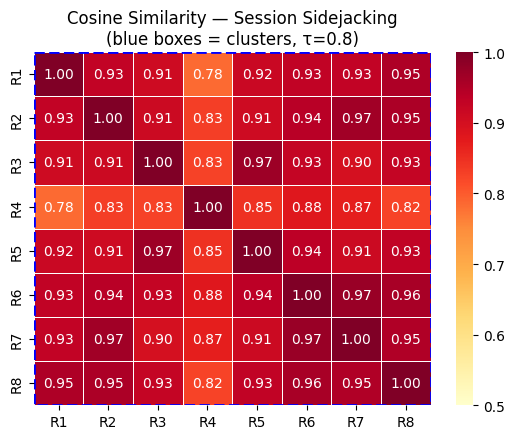

Cosine clusters: [['R1', 'R2', 'R3', 'R5', 'R6', 'R7', 'R8'], ['R4']]

NLI pairwise matrix (ENT/CON/NEU — same cluster iff both directions ENT):
      R1    R2    R3    R4    R5    R6    R7    R8
R1  SELF   NEU   CON   NEU   NEU   CON   NEU   ENT
R2   ENT  SELF   ENT   NEU   NEU   ENT   NEU   CON
R3   NEU   NEU  SELF   NEU   NEU   NEU   NEU   NEU
R4   ENT   NEU   ENT  SELF   ENT   ENT   ENT   ENT
R5   NEU   NEU   NEU   NEU  SELF   NEU   NEU   NEU
R6   ENT   NEU   ENT   NEU   NEU  SELF   NEU   NEU
R7   ENT   NEU   NEU   NEU   NEU   ENT  SELF   CON
R8   ENT   NEU   CON   NEU   NEU   ENT   NEU  SELF
NLI clusters: [['R1', 'R8'], ['R2'], ['R3'], ['R4'], ['R5'], ['R6'], ['R7']]


In [13]:
# ── Cosine similarity heatmap ────────────────────────────────
emb_ex = embedder.encode(ex.responses_nl)
sim_ex = cosine_similarity(emb_ex)
rlabels = [f"R{i+1}" for i in range(M)]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(sim_ex, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=rlabels, yticklabels=rlabels, vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax)
cl_cosine_ex = cluster_by_cosine(ex.responses_nl)
for cl in cl_cosine_ex:
    if len(cl) > 1:
        mn, mx = min(cl), max(cl)
        ax.add_patch(plt.Rectangle((mn, mn), mx - mn + 1, mx - mn + 1,
                                    fill=False, edgecolor="blue", linewidth=2, linestyle="--"))
ax.set_title(f"Cosine Similarity — {ex.attack}\n(blue boxes = clusters, τ={COSINE_THRESHOLD})")
plt.tight_layout()
plt.show()
print(f"Cosine clusters: {[['R'+str(j+1) for j in c] for c in cl_cosine_ex]}")

# ── NLI pairwise matrix ─────────────────────────────────────
cl_nli_ex = cluster_by_nli(ex.responses_nl)
n_ex = len(ex.responses_nl)
nli_labels = pd.DataFrame("", index=rlabels, columns=rlabels)
for i in range(n_ex):
    for j in range(n_ex):
        if i == j:
            nli_labels.iloc[i, j] = "SELF"
        else:
            r = nli(f"{ex.responses_nl[i]}</s></s>{ex.responses_nl[j]}", truncation=True)[0]
            nli_labels.iloc[i, j] = r["label"][:3]

print(f"\nNLI pairwise matrix (ENT/CON/NEU — same cluster iff both directions ENT):")
print(nli_labels.to_string())
print(f"NLI clusters: {[['R'+str(j+1) for j in c] for c in cl_nli_ex]}")


In [14]:
# ── Entropy breakdown ─────────────────────────────────────
lp = np.array(ex.log_probs)
pe = predictive_entropy(ex.log_probs)
se = semantic_entropy(cl_nli_ex, ex.log_probs)
dse = discrete_semantic_entropy(cl_nli_ex, M)

print("━━━ METRIC 1: PREDICTIVE ENTROPY ━━━")
print(f"  PE = -1/{M} × Σ log p(s_i|x)\n")
print(f"  {'Resp':<6} {'log p(s|x)':>12} {'tokens':>8} {'per-token':>10}")
print(f"  {'─'*38}")
for j, (lpi, nt) in enumerate(zip(ex.log_probs, ex.n_tokens)):
    print(f"  R{j+1:<5} {lpi:>12.2f} {nt:>8} {lpi/max(nt,1):>10.4f}")
print(f"\n  PE = -1/{M} × ({sum(ex.log_probs):.2f}) = {pe:.4f}")
print(f"  PE_norm = {pe:.4f} / {np.mean(ex.n_tokens):.0f} = {normalize_by_length(pe, ex.n_tokens):.4f}\n")

print("━━━ METRIC 2: DISCRETE SEMANTIC ENTROPY ━━━")
print(f"  DSE = -Σ_k (|C_k|/M) × log(|C_k|/M)\n")
for k, c in enumerate(cl_nli_ex):
    members = '+'.join([f'R{j+1}' for j in c])
    p_k = len(c) / M
    print(f"  C{k+1}: {members:<20} |C|/M = {p_k:.2f}")
print(f"\n  DSE = {dse:.4f}\n")

print("━━━ METRIC 3: SEMANTIC ENTROPY (MC, log-prob weighted) ━━━")
print(f"  SE = -Σ_k (|C_k|/M) × logsumexp(log-probs in C_k)\n")
for k, c in enumerate(cl_nli_ex):
    members = '+'.join([f'R{j+1}' for j in c])
    log_p_ck = logsumexp(lp[c])
    weight = len(c) / M
    print(f"  C{k+1}: {members:<20} weight={weight:.2f}  logsumexp={log_p_ck:.2f}  contrib={-weight*log_p_ck:.4f}")
print(f"\n  SE = {se:.4f}")
print(f"  SE_norm = {se:.4f} / {np.mean(ex.n_tokens):.0f} = {normalize_by_length(se, ex.n_tokens):.4f}\n")

print("━━━ SUMMARY ━━━")
print(f"  PE_norm  = {normalize_by_length(pe, ex.n_tokens):.6f}  (total uncertainty per token)")
print(f"  SE_norm  = {normalize_by_length(se, ex.n_tokens):.6f}  (semantic uncertainty per token)")
print(f"  DSE      = {dse:.6f}  (cluster disagreement, length-free)")
print(f"  Gap      = {normalize_by_length(pe - se, ex.n_tokens):.6f}  (phrasing noise per token)")
print(f"  SE <= PE: {'✓' if se <= pe + 1e-10 else '✗ BUG'}")

━━━ METRIC 1: PREDICTIVE ENTROPY ━━━
  PE = -1/8 × Σ log p(s_i|x)

  Resp     log p(s|x)   tokens  per-token
  ──────────────────────────────────────
  R1           -16.55      175    -0.0946
  R2           -21.56      184    -0.1172
  R3           -10.25      126    -0.0813
  R4           -75.47      477    -0.1582
  R5           -15.16      130    -0.1166
  R6           -12.66      174    -0.0728
  R7           -15.38      159    -0.0967
  R8           -10.91      175    -0.0623

  PE = -1/8 × (-177.94) = 22.2428
  PE_norm = 22.2428 / 200 = 0.1112

━━━ METRIC 2: DISCRETE SEMANTIC ENTROPY ━━━
  DSE = -Σ_k (|C_k|/M) × log(|C_k|/M)

  C1: R1+R8                |C|/M = 0.25
  C2: R2                   |C|/M = 0.12
  C3: R3                   |C|/M = 0.12
  C4: R4                   |C|/M = 0.12
  C5: R5                   |C|/M = 0.12
  C6: R6                   |C|/M = 0.12
  C7: R7                   |C|/M = 0.12

  DSE = 1.9062

━━━ METRIC 3: SEMANTIC ENTROPY (MC, log-prob weighted) ━━━
  SE

## 11. Results table

All three comparable metrics for every attack. Color gradient: red = high uncertainty, green = low uncertainty.

- **PE (norm):** per-token surprise. High = the model is unsure token-by-token.
- **SE (norm):** per-token semantic uncertainty. High = the model gives different meanings, not just different words.
- **Discrete SE:** cluster disagreement. 0 = all responses equivalent. $\log(5) \approx 1.61$ = all responses different.

In [15]:
df[["attack", "pe_norm", "se_norm", "dse", "clusters_nli", "avg_tokens"]].rename(columns={
    "pe_norm": "PE (norm)",
    "se_norm": "SE (norm)",
    "dse": "Discrete SE",
    "clusters_nli": "Clusters",
    "avg_tokens": "Avg Tok"
}).style.format({
    "PE (norm)": "{:.6f}",
    "SE (norm)": "{:.6f}",
    "Discrete SE": "{:.6f}",
    "Avg Tok": "{:.0f}"
}).background_gradient(
    subset=["PE (norm)", "SE (norm)", "Discrete SE"], cmap="RdYlGn_r"
)

,attack,PE (norm),SE (norm),Discrete SE,Clusters,Avg Tok
0,Session Credential Falsification through Manipulation,0.162311,0.106164,0.735622,3,327
1,Session Credential Falsification through Prediction,0.017100,0.004570,0.000000,1,176
2,Session Sidejacking,0.111214,0.107681,1.906155,7,200
3,Cross Site Tracing,0.136216,0.090496,0.900256,3,199
4,Reusing Session IDs (aka Session Replay),0.031643,0.010588,0.562335,2,190
5,Session Fixation,0.032821,0.016869,1.073543,4,98
6,Cross Site Identification,0.096478,0.071254,0.974315,3,152
7,"Removal of filters: Input filters, output filters, data masking",0.132024,0.081026,1.073543,4,302
8,Removing/short-circuiting 'Purse' logic: removing/mutating 'cash' decrements,0.160693,0.152880,1.906155,7,235
9,Subverting Environment Variable Values,0.068297,0.055617,1.255482,4,121


## 12. Plots

Three visualizations:

- **12a.** Bar chart: all three metrics per attack, side by side. Quickly identifies which attacks have high uncertainty.
- **12b.** Scatter: PE\_norm vs SE\_norm. Both are per-token entropy on the same scale, so the y=x diagonal is meaningful. Points below the line = clustering reduced uncertainty (phrasing variation removed). Points on the line = no clustering benefit (genuine semantic disagreement).
- **12c.** Histograms: distribution of each metric across all attacks. Shows whether most attacks are low-uncertainty (model is generally reliable) or spread out (mixed reliability).

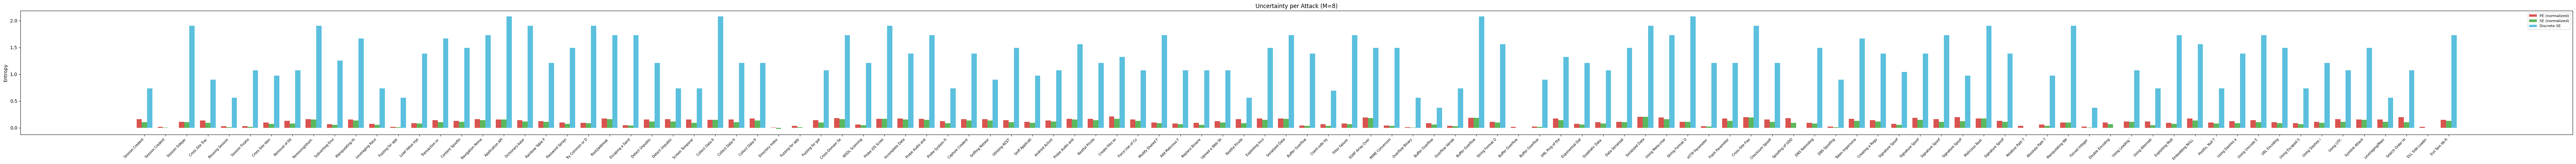

In [16]:
# ── 12a. Three metrics per attack ────────────────────────
fig, ax = plt.subplots(figsize=(max(14, len(df) * 0.7), 5))
x = np.arange(len(df))
w = 0.25
ax.bar(x - w, df.pe_norm, w, label="PE (normalized)", color="#d9534f")
ax.bar(x,     df.se_norm, w, label="SE (normalized)", color="#5cb85c")
ax.bar(x + w, df.dse,     w, label="Discrete SE", color="#5bc0de")
ax.set_xticks(x)
ax.set_xticklabels([a[:15] for a in df.attack], fontsize=7, rotation=45, ha="right")
ax.set_ylabel("Entropy")
ax.set_title(f"Uncertainty per Attack (M={M})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

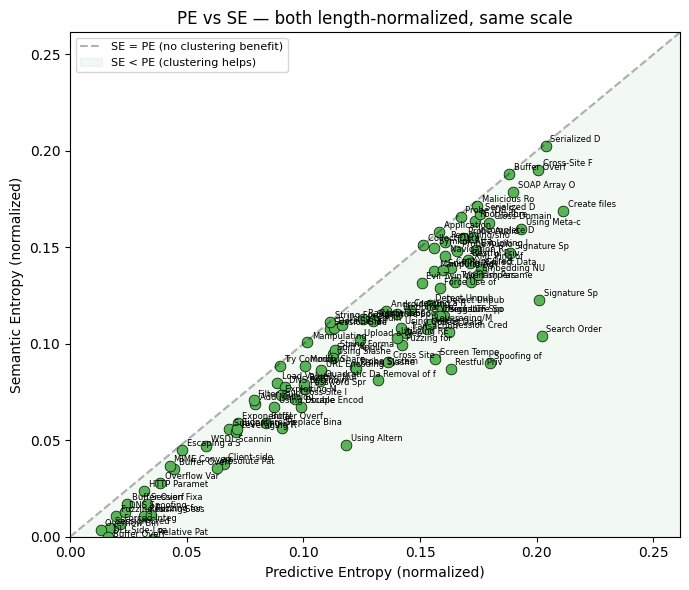

SE <= PE guaranteed. Gap = phrasing uncertainty removed by clustering.


In [17]:
# ── 12b. PE_norm vs SE_norm scatter ────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df.pe_norm, df.se_norm, s=60, c="#5cb85c", edgecolors="black", linewidths=0.5)
for _, row in df.iterrows():
    ax.annotate(row.attack[:12], (row.pe_norm + 0.002, row.se_norm + 0.002), fontsize=6)
lim = max(df.pe_norm.max(), df.se_norm.max()) + 0.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="SE = PE (no clustering benefit)")
ax.fill_between([0, lim], [0, lim], [0, 0], alpha=0.05, color="green",
                label="SE < PE (clustering helps)")
ax.set_xlabel("Predictive Entropy (normalized)")
ax.set_ylabel("Semantic Entropy (normalized)")
ax.set_title("PE vs SE — both length-normalized, same scale")
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()
print("SE <= PE guaranteed. Gap = phrasing uncertainty removed by clustering.")

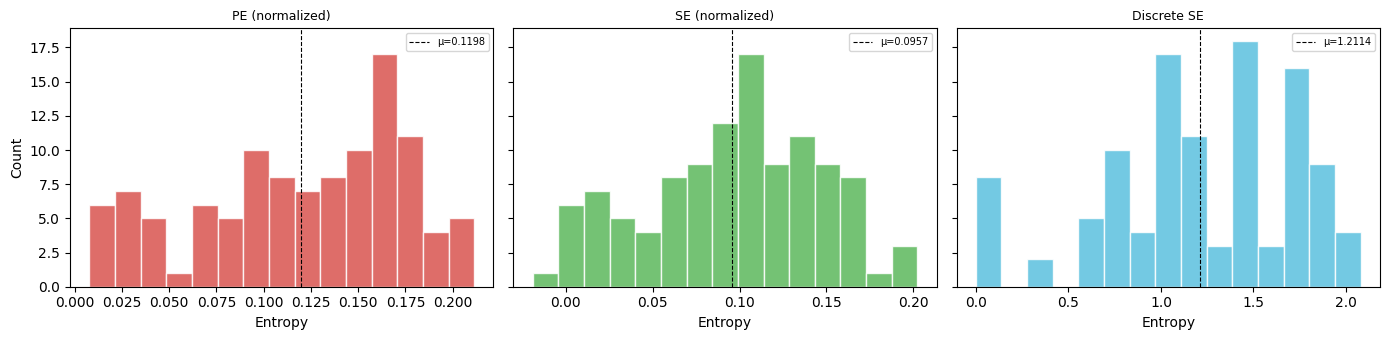

In [18]:
# ── 12c. Distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, col, label, color in zip(axes,
    ["pe_norm", "se_norm", "dse"],
    ["PE (normalized)", "SE (normalized)", "Discrete SE"],
    ["#d9534f", "#5cb85c", "#5bc0de"]):
    ax.hist(df[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Entropy")
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=0.8,
               label=f"μ={df[col].mean():.4f}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

## 13. Highest-uncertainty attacks

Top 10 attacks ranked by normalized semantic entropy ($SE_{\text{norm}}$). These are the attacks where the model is **least confident about the meaning** of its mitigations — different runs produce semantically different lists.

These outputs should be treated with caution: the mitigations may be hallucinated, incomplete, or inconsistently prioritized. Consider manual review or using a more capable model for these specific attacks.

In [ ]:
top_n = min(10, len(df))
df.nlargest(top_n, "se_norm")[
    ["attack", "pe_norm", "se_norm", "dse", "clusters_nli", "avg_tokens"]
].style.format({
    "pe_norm": "{:.6f}", "se_norm": "{:.6f}", "dse": "{:.6f}", "avg_tokens": "{:.0f}"
}).background_gradient(subset=["pe_norm", "se_norm", "dse"], cmap="Reds")

## 14. Save results

Exports a CSV with one row per attack. **Primary columns** (comparable across attacks):

- `pe_norm` — predictive entropy per token: how surprised is the model?
- `se_norm` — semantic entropy per token: how much semantic disagreement?
- `dse` — discrete semantic entropy: how many distinct meanings? (no log-probs needed)

**Reference columns** (raw, not comparable across attacks): `pe`, `se`.

**Interpretation guide:**
- High `se_norm` + high `dse` → the model gives genuinely different answers → **unreliable**
- Low `se_norm` + low `dse` → the model is semantically consistent → **reliable**
- High `pe_norm` but low `se_norm` → different phrasing, same meaning → **reliable** (just verbose)

In [ ]:
# ── Build filename with model name ──
model_tag = OLLAMA_MODEL.replace(":", "_").replace("/", "_") if BACKEND == "ollama" else LLM_NAME.split("/")[-1]
fname = f"entropy_results_{model_tag}.csv"

# ── Save ──
save_cols = ["attack",
             "pe_norm", "se_norm", "dse",      # comparable across attacks
             "clusters_nli", "avg_tokens"]
clean_df = df[save_cols].copy()
clean_df.to_csv(fname, index=False)
print(f"Saved {len(clean_df)} rows → {fname}")
print(f"Model: {OLLAMA_MODEL if BACKEND == 'ollama' else LLM_NAME}\n")
print("Columns:")
print("  pe_norm — predictive entropy / avg tokens (per-token surprise)")
print("  se_norm — semantic entropy / avg tokens (per-token, cluster-weighted)")
print("  dse     — discrete semantic entropy (cluster counts, length-free)")
print("  pe, se  — raw values (not comparable across attacks)")
print()
clean_df